<a href="https://colab.research.google.com/github/rui209/BRD4-Selective-Inhibitor-VS/blob/main/PHM5005_Group12_v3_PaddedImages_Recategorized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Detection and Grading of Diabetic Retinopathy using Deep Learning
- **Objective**: Train and evaluate deep-learning models in classification of diabetic retinopathy grades
- **Reference**:
  - Decencière et al.. Feedback on a publicly distributed database: the Messidor database.Image Analysis & Stereology, v. 33, n. 3, p. 231-234, aug. 2014. ISSN 1854-5165.Available at: http://www.ias-iss.org/ojs/IAS/article/view/1155 or http://dx.doi.org/10.5566/ias.1155.

In [ ]:
# Import basic modules
import re
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [ ]:
# Install supporting libraries
!pip install torchvista torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.0 MB/s eta 0:00:00


## Download and organize data
- Data has already been pre-downloaded and moved to a separate google drive folder: `https://drive.google.com/drive/folders/1URDSCPL2j6VB1MMf-TezmhSQqAgTC31Y?usp=drive_link`

In [ ]:
# Install gdown
!pip install -q gdown

# Download all files from Google Drive folder
!gdown --folder https://drive.google.com/drive/folders/1URDSCPL2j6VB1MMf-TezmhSQqAgTC31Y?usp=drive_link

Retrieving folder contents
Processing file 1E6a2J19OTTFay5iQJSF9d08Tm9acRSak Base11.zip
Processing file 1oCnZ3dtSB_jfKrMnfWpzJrODZGCZ3bDr Base12.zip
Processing file 1O_BqzFeCaBxGZBmal232w4PWuCiy9AlB Base13.zip
Processing file 1WUg9G8Pf7HDcHe73sHftsqD05aezuOAI Base14.zip
Processing file 1laBxvoCoiQLel0vfBnwFB_sbTgkN_VG_ Base21.zip
Processing file 1jqnRt0V_Mt7WgQYwOh29CgwRi6_Vl3jh Base22.zip
Processing file 1d_aQClfvxBYb-kIFGbZdewLaPdHQ14Gw Base23.zip
Processing file 14nMMheBIffHt6zy5r3NIfiEhxbE3X_q1 Base24.zip
Processing file 1Ifvj2lZ0_G0U0vyTgpCe5-qhrQIW9sQv Base31.zip
Processing file 1DF_h_Y6VM_uyH4qPYXSVuYJS0wTLrFIP Base32.zip
Processing file 1LeEG68-MG93xOYpg-FvEZfxichAcZTmV Base33.zip
Processing file 16LaGlrwYflLVfEIJC3Lr0hRMr1VzGueT Base34.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1E6a2J19OTTFay5iQJSF9d08Tm9acRSak
From (redirected): https://drive.google

In [ ]:
import shutil
import zipfile
from pathlib import Path

# Path to dataset folder
dataset_path = Path('messidor_dataset')

# Loop over all zip files
for zip_path in dataset_path.glob('*.zip'):
    folder = dataset_path / zip_path.stem   # Folder = zip file name without .zip
    folder.mkdir(exist_ok=True)             # Create folder
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder)          # Extract into folder
    zip_path.unlink()                       # Delete the zip file

# List of folders that have nested folders
nested_folders = ['messidor_dataset/Base11', 'messidor_dataset/Base13']

for outer in nested_folders:
    outer_path = Path(outer)

    # Get the inner folder (should be only one)
    inner_folders = [f for f in outer_path.iterdir() if f.is_dir()]

    if len(inner_folders) == 1:
        inner_path = inner_folders[0]

        # Move all files from inner folder to outer folder
        for file in inner_path.iterdir():
            shutil.move(str(file), outer_path)

        # Remove the now-empty inner folder
        inner_path.rmdir()
        print(f"Moved files from {inner_path} to {outer_path} and removed inner folder.")
    else:
        print(f"Skipping {outer_path}: found {len(inner_folders)} inner folders")


Moved files from messidor_dataset/Base11/Base11 to messidor_dataset/Base11 and removed inner folder.
Moved files from messidor_dataset/Base13/Base13 to messidor_dataset/Base13 and removed inner folder.


## Extract label annotations and perform train-validation-test split

In [ ]:
# Extract load the .xls files containing information of image filename and the corresponding labelled retinopathy grades
annot_files = glob.glob(f"/content/messidor_dataset/*/*.xls")

# Merge all annotations into a single dataframe and include the sub-directory name as a column (i.e. "Base*")
annotations = []

for f in annot_files:
  annot_df = pd.read_excel(f)
  basename = os.path.basename(f)
  annot_df['SUB_DIR'] = re.split(r'[_. ]', basename)[1]
  annotations.append(annot_df)

annotations = pd.concat(annotations)
annotations.columns = ['IMAGE_NAME', 'SOURCE', 'RETINOPATHY_GRADE', 'MACULAR_EDEMA_RISK', 'SUB_DIR']
annotations.head(3)


,IMAGE_NAME,SOURCE,RETINOPATHY_GRADE,MACULAR_EDEMA_RISK,SUB_DIR
0,20051130_54257_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32
1,20051130_54301_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32
2,20051130_54323_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32


In [ ]:
# Create binary labels ("BINARY_GRADE") - RETINOPATHY_GRADE 1_2 versus RETINOPATHY_GRADE 3_4
annotations['BINARY_GRADE'] = annotations['RETINOPATHY_GRADE'].apply(lambda x: 1 if x > 1 else 0)
annotations.head(3)

,IMAGE_NAME,SOURCE,RETINOPATHY_GRADE,MACULAR_EDEMA_RISK,SUB_DIR,BINARY_GRADE
0,20051130_54257_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32,0
1,20051130_54301_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32,0
2,20051130_54323_0400_PP.tif,LaTIM - CHU de BREST,0,0,Base32,0


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 25 # Main seed to used throughout analysis
MAIN_LABEL = 'BINARY_GRADE' # Main label column to use

# Split data into train, validation, test - 80/20/20 and stratify by label
train_df, val_test_df = train_test_split(annotations, test_size=0.2, random_state=SEED, stratify=annotations[MAIN_LABEL])

val_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=SEED, stratify=val_test_df[MAIN_LABEL])

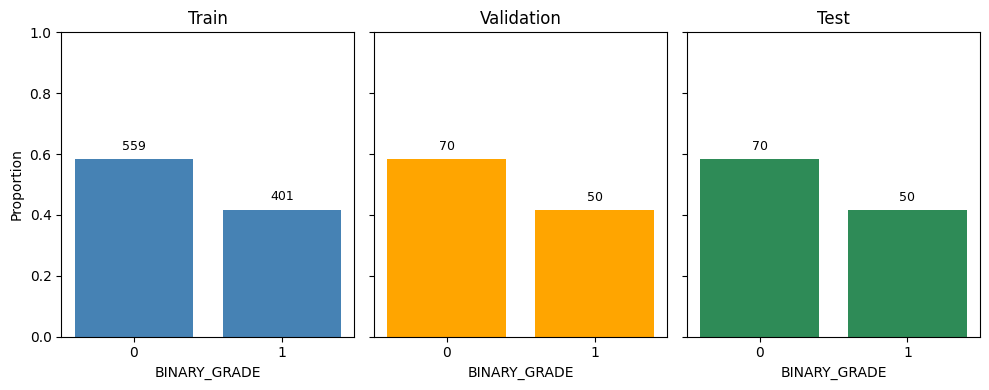

In [ ]:
# Plot to check visualize distribution of 'RETINOPATHY_GRADE' across sets
train_props = train_df[MAIN_LABEL].value_counts(normalize=True).sort_index()
val_props   = val_df[MAIN_LABEL].value_counts(normalize=True).sort_index()
test_props  = test_df[MAIN_LABEL].value_counts(normalize=True).sort_index()

train_counts = train_df[MAIN_LABEL].value_counts().sort_index()
val_counts   = val_df[MAIN_LABEL].value_counts().sort_index()
test_counts  = test_df[MAIN_LABEL].value_counts().sort_index()

# Labels
labels = train_props.index.astype(str).tolist()

# Create figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Combine all data for easy looping
datasets = [
    ("Train", train_props, train_counts, "steelblue"),
    ("Validation", val_props, val_counts, "orange"),
    ("Test", test_props, test_counts, "seagreen"),
]

# Plot
for ax, (title, prop_data, count_data, color) in zip(axes, datasets):
    bars = ax.bar(labels, prop_data, color=color)
    ax.set_title(title)
    ax.set_xlabel(MAIN_LABEL)
    ax.set_ylim(0, 1)

    # Add count labels on top of each bar
    for bar, count in zip(bars, count_data):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,              # position slightly above the bar
            f"{count}",                 # show raw count
            ha="center",
            va="bottom",
            fontsize=9
        )

# Common Y label
axes[0].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

## Preprocessing
- Create `CustomImageDataset`
- Compute `mean` and `std` for normalization
- Define transformations: Resize, Normalize
- Defining `DataLoader`

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
  def __init__(self, df, transform=None):
    self.df = df
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_name = self.df.iloc[idx]['IMAGE_NAME']
    img_sub_dir = self.df.iloc[idx]['SUB_DIR']
    img_path = f"/content/messidor_dataset/{img_sub_dir}/{img_name}"
    image = Image.open(img_path).convert('RGB')
    label = torch.tensor(self.df.iloc[idx][MAIN_LABEL], dtype=torch.long)

    if self.transform:
      image = self.transform(image)

    return image, label

In [ ]:
# Imbalanced training set - perform undersampling of majority class
minority_class_size = train_df[MAIN_LABEL].value_counts().min() # Class:1

majority_class = train_df[train_df[MAIN_LABEL] == 0].sample(n=minority_class_size, random_state=SEED)

train_df = pd.concat([majority_class, train_df[train_df[MAIN_LABEL] == 1]])

print("New distribution of training set after undersampling:")
print(train_df[MAIN_LABEL].value_counts())

New distribution of training set after undersampling:
BINARY_GRADE
0    401
1    401
Name: count, dtype: int64


In [ ]:
# Calculate `mean` and `std` for the channels in training set

def calculate_dataset_stats(df, target_size=(224,224), batch_size=100):
  """
  Calculates mean and std for dataset - done in matches to reduce memory issues

  Args:
    df: DataFrame containing image paths
    target_size: Tuple of (height, width) for resizing
    batch_size: Number of images to process at once

  Returns:
    mean, std: Numpy arrays of shape (3,) for RGB channels
  """

  # Choose a common shape (H, W) for all images
  TARGET_H, TARGET_W = target_size
  C = 3 # RGB

  # Running statistics
  pixel_sum = np.zeros(C, dtype=np.float32)
  pixel_sq_sum = np.zeros(C, dtype=np.float32)
  total_pixels = 0

  # Images not consistently of the same resolution and aspect ratios - Pad to square image
  def pad_to_square(img, fill=0):
        width, height = img.size
        if width == height:
            return img
        max_side = max(width, height)
        new_img = Image.new('RGB', (max_side, max_side), fill)
        paste_x = (max_side - width) // 2
        paste_y = (max_side - height) // 2
        new_img.paste(img, (paste_x, paste_y))
        return new_img

  # Process in batches
  num_images = len(df)
  for start_idx in range(0, num_images, batch_size):
      end_idx = min(start_idx + batch_size, num_images)
      batch_imgs = []

      for i in range(start_idx, end_idx):
            row = df.iloc[i]
            img_path = os.path.join("/content/messidor_dataset", row['SUB_DIR'], row['IMAGE_NAME'])
            img = Image.open(img_path).convert('RGB')
            img = pad_to_square(img, fill=0)
            img = img.resize((TARGET_W, TARGET_H))
            img = np.array(img, dtype=np.float32) / 255.0
            batch_imgs.append(img)

  if batch_imgs:
          batch_array = np.array(batch_imgs)
          # Update running statistics
          pixel_sum += batch_array.sum(axis=(0, 1, 2))
          pixel_sq_sum += (batch_array ** 2).sum(axis=(0, 1, 2))
          total_pixels += batch_array.shape[0] * TARGET_H * TARGET_W

  # Calculate final mean and std
  mean = pixel_sum / total_pixels
  std = np.sqrt((pixel_sq_sum / total_pixels) - (mean ** 2))

  return mean, std

# Define TARGET_SIZE
TARGET_SIZE = (224, 224)

# Calculate mean and std for training set
print("Calculating dataset statistics...")
TRAIN_MEAN, TRAIN_STD = calculate_dataset_stats(train_df, target_size=TARGET_SIZE)
print(f"Dataset mean: {TRAIN_MEAN}")
print(f"Dataset std : {TRAIN_STD}")

Calculating dataset statistics...
Dataset mean: [0.25384837 0.12888266 0.04147356]
Dataset std : [0.38998008 0.19258003 0.06941259]


In [ ]:
# Define image transformation: pad to square, resize, convert image to tensor and normalize to [-1, 1]
# Note: Not all images are of the same size, so resizing is essential
# From source: "Images were captured using 8 bits per color plane at 1440*960, 2240*1488 or 2304*1536 pixels."

# Function to pad image to square (black background)
def pad_to_square(img, fill=0):
    w, h = img.size
    max_wh = max(w, h)
    pad_left = (max_wh - w) // 2
    pad_top = (max_wh - h) // 2
    pad_right = max_wh - w - pad_left
    pad_bottom = max_wh - h - pad_top
    return transforms.functional.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=fill)

# Transformations
transform = transforms.Compose([
    transforms.Lambda(lambda img: pad_to_square(img, fill=0)), # use function instead
    # transforms.RandomHorizontalFlip(), # can consider applying if needed
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# Load the training, validation, and test sets with defined transformation
train_ds = CustomImageDataset(train_df, transform=transform)
val_ds   = CustomImageDataset(val_df,   transform=transform)
test_ds  = CustomImageDataset(test_df,  transform=transform)

In [ ]:
# Compute class weights
class_counts = train_df[MAIN_LABEL].value_counts().sort_index()
num_samples = sum(class_counts)
class_weights = [num_samples / (len(class_counts) * count) for count in class_counts]

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1., 1.])


In [ ]:
from torch.utils.data import DataLoader

# Setting DataLoader
BATCH_SIZE = 32

# Prepare PyTorch DataLoader objects for batch processing
# Shuffle the training data for better training performance
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

### Image inspection
- Define function to plot images

In [ ]:
# Helper function to convert tensors to RGB
def tensor_to_rgb(img, mean, std):
  img2show = img.clone().cpu()

  # Reverse normalization (if needed)
  mu = torch.as_tensor(mean).reshape(3, 1, 1)
  sigma = torch.as_tensor(std).reshape(3, 1, 1)
  img2show = img2show * sigma + mu
  img2show = img2show.clamp(0,1)

  # Reorder channels for matplotlib
  img2show = np.transpose(img2show.numpy(), (1,2,0)) # [C,H,W] -> [H,W,C]

  return(img2show)

# Function to plot image ()
def plot_image(img, lbl, pred_class = None, mean = TRAIN_MEAN, std = TRAIN_STD):

    img2show = tensor_to_rgb(img, mean, std) # Get RGB image

    label = lbl.item() # Get label value

    # Build title for ground truth label
    title = f"True label: {label}"

    # Add prediction label if specified
    if pred_class is not None:
        title += f"\nPredicted label: {pred_class}"

    # Plot
    plt.imshow(img2show)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
# Test plot function
images, labels = next(iter(train_loader))
print(labels)

tensor([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 0, 0, 1, 1])


tensor([1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
        0, 0, 1, 0, 0, 1, 0, 1])


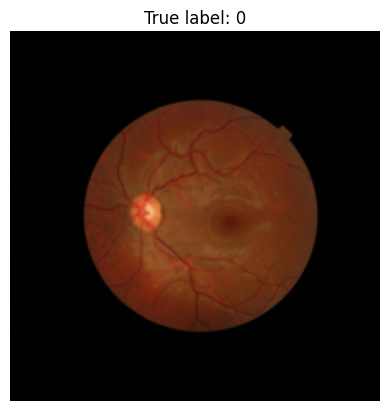

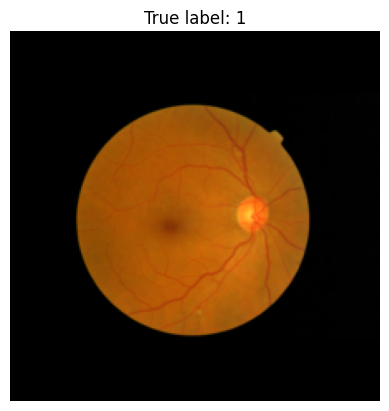

In [ ]:
images, labels = next(iter(train_loader))
labels_toview = [0, 1]

while not all(l in labels for l in labels_toview):
  images, labels = next(iter(train_loader))

print(labels)

# Fetch first indices of each label
first_indices = []
for l in labels_toview:
  matches = (labels == l).nonzero(as_tuple=True)[0]
  if len(matches) > 0:
    first_indices.append(matches[0].item())

# Visual comparison between images with different grades
for idx in first_indices:
  plot_image(images[idx], labels[idx])

In [ ]:
# Check shape of images and labels
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Training and Evaluation functions

In [ ]:
# ---- Training and validation epochs ----
def train_one_epoch(model, loader, criterion, optimizer, metric, device):
  model.train()
  total_loss = 0.0
  metric.reset()

  for xb, yb in tqdm(loader, desc="Training", leave=False):
    xb, yb = xb.to(device), yb.squeeze().to(device)
    optimizer.zero_grad()
    output = model(xb)
    loss = criterion(output, yb)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    metric.update(output, yb)

  avg_loss = total_loss / max(1, len(loader))
  avg_metric = metric.compute().item()

  return avg_loss, avg_metric

def validate_one_epoch(model, loader, criterion, metric, device):
  model.eval()
  total_loss = 0.0
  metric.reset()

  with torch.no_grad():
    for xb, yb in tqdm(loader, desc="Validation", leave=False):
      xb, yb = xb.to(device), yb.squeeze().to(device)
      output = model(xb)
      loss = criterion(output, yb)

      total_loss += loss.item()
      metric.update(output, yb)

  avg_loss = total_loss / max(1, len(loader))
  avg_metric = metric.compute().item()

  return avg_loss, avg_metric

In [ ]:
# Visualization of loss curves
def loss_curves(running_train_loss,
                running_val_loss,
                running_train_metric,
                running_val_metric,
                metric = 'Accuracy'):
  plt.figure(figsize=(8,5))
  plt.plot(running_train_loss, label='Train Loss')
  plt.plot(running_val_loss, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training & Validation Loss Curves')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Visualization metric curves (accuracy)                                              #
  plt.figure(figsize=(8,5))
  plt.plot(running_train_metric, label='Train Metric')
  plt.plot(running_val_metric, label='Validation Metric')
  plt.xlabel('Epoch')
  plt.ylabel(metric)
  plt.title('Training & Validation Metric Curves')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, precision_recall_fscore_support

# Test Evaluation
def evaluate_model(
    model,
    test_loader,
    criterion,
    test_metric,
    checkpoint_file=None,
    device=None,
    class_names=None,
    show_confusion_matrix=True,
    show_classification_report=True,
    figsize=(10, 8)
):
    """
    Comprehensive test evaluation function for PyTorch models.

    Args:
        model: PyTorch model to evaluate
        test_loader: DataLoader for test set
        criterion: Loss function
        test_metric: TorchMetrics metric object (e.g., Accuracy)
        checkpoint_file: Path to checkpoint file (if None, uses current model state)
        device: Device to run evaluation on (if None, auto-detects)
        class_names: List of class names for better visualization (optional)
        show_confusion_matrix: Whether to plot confusion matrix
        show_classification_report: Whether to print classification report
        figsize: Figure size for confusion matrix plot

    Returns:
        dict: Dictionary containing:
            - 'test_loss': Average test loss
            - 'test_accuracy': Test accuracy (or other metric value)
            - 'predictions': List of predicted labels
            - 'labels': List of true labels
            - 'confusion_matrix': Confusion matrix array
    """

    # Auto-detect device if not provided
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load checkpoint if provided
    if checkpoint_file is not None:
        print(f"Loading model from {checkpoint_file}...")
        checkpoint = torch.load(checkpoint_file, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        if "best_val_loss" in checkpoint:
            print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
        if "epoch" in checkpoint:
            print(f"Checkpoint from epoch: {checkpoint['epoch'] + 1}")

    # Ensure metric is on correct device
    test_metric = test_metric.to(device)

    # Initialize tracking variables
    test_loss_sum = 0.0
    test_metric.reset()
    all_preds = []
    all_labels = []

    # Evaluate on test set
    model.eval()
    print("\nEvaluating on test set...")

    with torch.no_grad():
        for xb, yb in tqdm(test_loader, desc="Testing"):
            xb, yb = xb.to(device), yb.view(-1).to(device)

            # Forward pass
            output = model(xb)
            loss = criterion(output, yb)

            # Get predictions
            preds = output.argmax(dim=1)

            # Update metrics
            test_loss_sum += loss.item()
            test_metric.update(output, yb)

            # Collect labels and predictions
            all_labels.extend(yb.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Calculate final metrics
    avg_test_loss = test_loss_sum / len(test_loader)
    test_metric_value = test_metric.compute().item()

    # Print results
    print("\n" + "="*60)
    print("TEST RESULTS")
    print("="*60)
    print(f"Test Loss:   {avg_test_loss:.4f}")
    print(f"Test Metric: {test_metric_value:.4f} ({test_metric_value*100:.2f}%)")
    print(f"Total Samples: {len(all_labels)}")
    print("="*60)

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Infer number of classes from confusion matrix
    num_classes = cm.shape[0]

    # Classification report
    if show_classification_report:
        print("\nCLASSIFICATION REPORT")
        print("="*60)
        if class_names is not None:
            target_names = class_names
        else:
            target_names = [f"Class {i}" for i in range(num_classes)]

        print(classification_report(
            all_labels,
            all_preds,
            target_names=target_names,
            digits=4
        ))

    # Plot confusion matrix
    if show_confusion_matrix:
        plt.figure(figsize=figsize)

        if class_names is not None:
            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=class_names
            )
        else:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)

        disp.plot(cmap="Blues", values_format='d')
        plt.title(f"Confusion Matrix (Metric: {test_metric_value:.2%})", fontsize=14, pad=20)
        plt.xlabel("Predicted Label", fontsize=12)
        plt.ylabel("True Label", fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    # Calculate per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None
    )

    print("\nPER-CLASS METRICS")
    print("="*60)
    for i in range(num_classes):
        class_name = class_names[i] if class_names else f"Class {i}"
        print(f"{class_name:15s} | "
              f"Precision: {precision[i]:.4f} | "
              f"Recall: {recall[i]:.4f} | "
              f"F1: {f1[i]:.4f} | "
              f"Support: {support[i]:4d}")

    # Return results
    results = {
        'test_loss': avg_test_loss,
        'test_metric': test_metric_value,
        'predictions': all_preds,
        'labels': all_labels,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': support
    }

    return results

## Simple CNN architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
  def __init__(self, num_classes, input_size=224):
    super(SimpleCNN, self).__init__()

    self.input_size = input_size

    # Convolutional layers
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

    # Max pooling layer
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    # Calculate size after convolutions and pooling
    # Each pooling layer dvides dimensions by 2
    self.feature_size = input_size // (2 ** 3) # 3 pooling layers
    self.flattened_size = 128 * self.feature_size * self.feature_size

    # Fully connected layers
    self.fc1 = nn.Linear(in_features=self.flattened_size, out_features=256) # after 3 pooling layers, 224 -> 112 -> 56 -> 28
    self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    # Dropout for regularization
    self.dropout = nn.Dropout(p=0.5)

  def forward(self, x):
    # Convolutional layers
    x = self.pool(F.relu(self.conv1(x))) # 224 -> 112
    x = self.pool(F.relu(self.conv2(x))) # 112 -> 56
    x = self.pool(F.relu(self.conv3(x))) # 56 -> 28

    # Flatten for fully connected layers
    x = x.view(x.size(0), -1)

    # Full connected layers
    x = F.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)

    return x

### Initial Set-up

In [ ]:
# Instantiate model
NUM_CLASSES = len(train_df[MAIN_LABEL].unique())
INPUT_SIZE = TARGET_SIZE[0]
model = SimpleCNN(num_classes=NUM_CLASSES, input_size=INPUT_SIZE)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# Defining basic parameters
# Fix seeds for different RNGs
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100

# Paths
MODEL_TYPE = 'SIMPLECNN'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

print(DEVICE)

# Move the model to GPU
model = model.to(DEVICE)

cuda


In [ ]:
from torchmetrics.classification import MulticlassF1Score
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Set up metrics
metric_name = 'MulticlassF1Score'
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up scheduler
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

In [ ]:
# ---- Configuration ----
REPORT_INTERVAL = 5 # print losses every 5 epochs
PATIENCE = 10
MIN_DELTA = 1e-4 # minimum change to qualify as improvement

### Training / Validation

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.7099)
Epoch 1/100 | Train loss: 0.8862, F1: 0.548 | Val loss: 0.7099, F1: 0.392


Epoch 2: Saved new best model (val_loss=0.6828)


Epoch 3: Saved new best model (val_loss=0.6652)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 0.6554, F1: 0.591 | Val loss: 0.6762, F1: 0.605


...

Epoch 22: No improvement (6/10)


Epoch 23: No improvement (7/10)


Epoch 24: No improvement (8/10)


Epoch 25: No improvement (9/10)
Epoch 25/100 | Train loss: 0.5950, F1: 0.678 | Val loss: 0.6244, F1: 0.648


Epoch 26: No improvement (10/10)
Epoch 26: Early stopping triggered.


### Inspecting performances

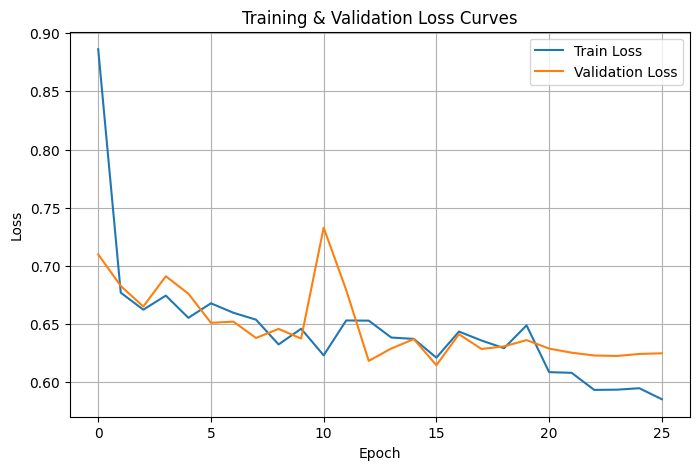

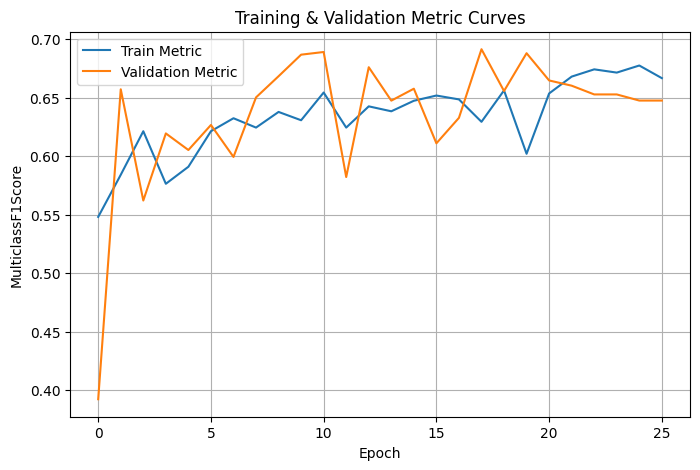

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

### Evaluation

Loading model from /content/checkpoint_SIMPLECNN_F1.pt...
Best validation loss: 0.6147
Checkpoint from epoch: 16

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:06<00:00,  1.74s/it]


TEST RESULTS
Test Loss:   0.6249
Test Metric: 0.6180 (61.80%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.6629    0.8429    0.7421        70
     Class 1     0.6452    0.4000    0.4938        50

    accuracy                         0.6583       120
   macro avg     0.6540    0.6214    0.6180       120
weighted avg     0.6555    0.6583    0.6387       120



<Figure size 1000x800 with 0 Axes>

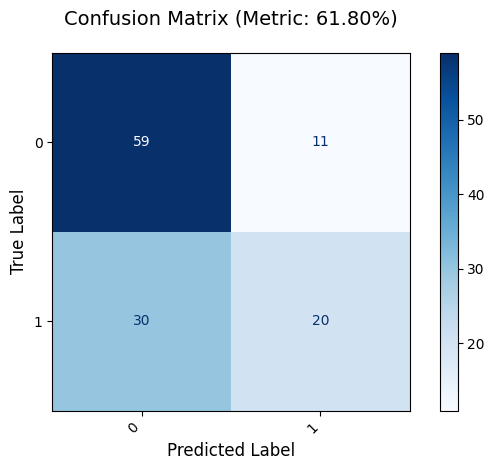


PER-CLASS METRICS
Class 0         | Precision: 0.6629 | Recall: 0.8429 | F1: 0.7421 | Support:   70
Class 1         | Precision: 0.6452 | Recall: 0.4000 | F1: 0.4938 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

## Modern architecture (ResNet)

#### Training ResNet from scratch

In [ ]:
import torchvision.models as models

# Training ResNet model from scratch
model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.9027)
Epoch 1/100 | Train loss: 0.8022, F1: 0.582 | Val loss: 0.9027, F1: 0.448


Epoch 2: Saved new best model (val_loss=0.6405)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 0.6734, F1: 0.573 | Val loss: 0.6785, F1: 0.542


...

Epoch 14: No improvement (6/10)


Epoch 15: No improvement (7/10)
Epoch 15/100 | Train loss: 0.6328, F1: 0.648 | Val loss: 0.6762, F1: 0.603


Epoch 16: No improvement (8/10)


Epoch 17: No improvement (9/10)


Epoch 18: No improvement (10/10)
Epoch 18: Early stopping triggered.


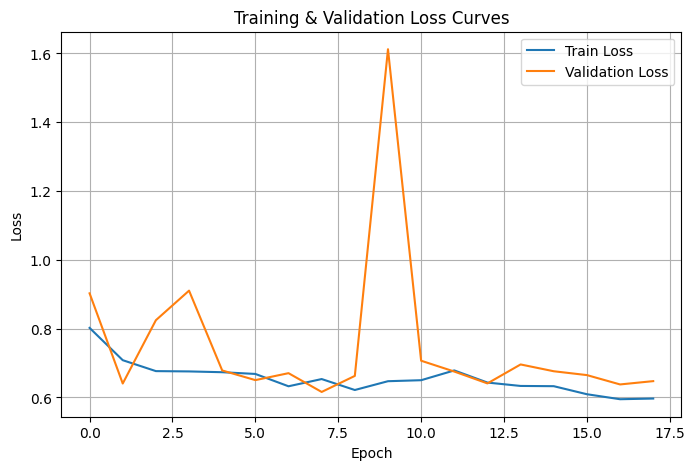

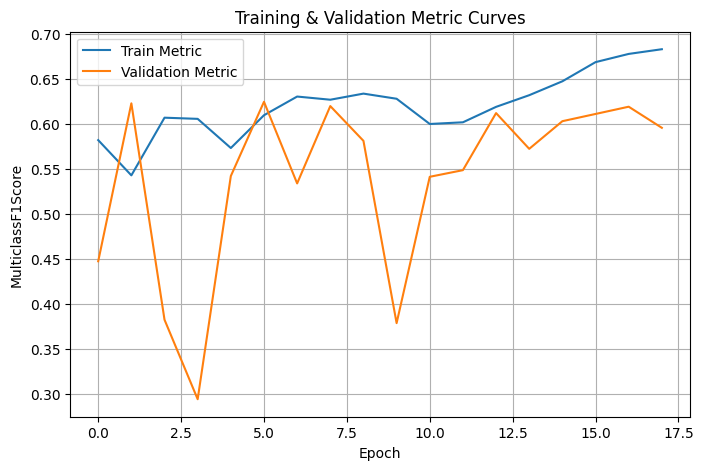

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET18_F1.pt...
Best validation loss: 0.6160
Checkpoint from epoch: 8

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.40s/it]


TEST RESULTS
Test Loss:   0.6272
Test Metric: 0.5691 (56.91%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.6373    0.9286    0.7558        70
     Class 1     0.7222    0.2600    0.3824        50

    accuracy                         0.6500       120
   macro avg     0.6797    0.5943    0.5691       120
weighted avg     0.6727    0.6500    0.6002       120



<Figure size 1000x800 with 0 Axes>

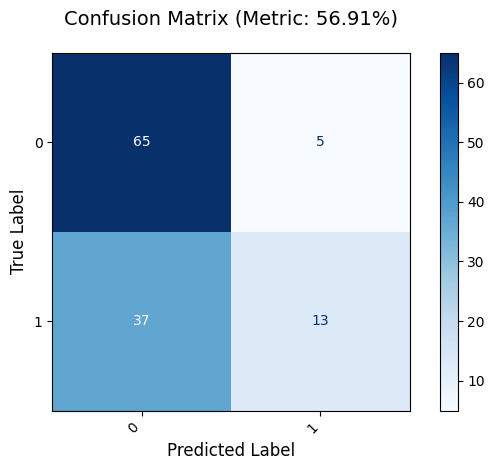


PER-CLASS METRICS
Class 0         | Precision: 0.6373 | Recall: 0.9286 | F1: 0.7558 | Support:   70
Class 1         | Precision: 0.7222 | Recall: 0.2600 | F1: 0.3824 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

#### Fine-tuning pretrained ResNet

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_FT'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Minimize forgetting
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.6937)
Epoch 1/100 | Train loss: 0.5630, F1: 0.723 | Val loss: 0.6937, F1: 0.595


Epoch 2: No improvement (1/10)


Epoch 3: No improvement (2/10)


Epoch 4: No improvement (3/10)


Epoch 5: No improvement (4/10)
Epoch 5/100 | Train loss: 0.1670, F1: 0.946 | Val loss: 0.7727, F1: 0.699


...

Epoch 21: No improvement (6/10)


Epoch 22: No improvement (7/10)


Epoch 23: No improvement (8/10)


Epoch 24: No improvement (9/10)


Epoch 25: No improvement (10/10)
Epoch 25: Early stopping triggered.


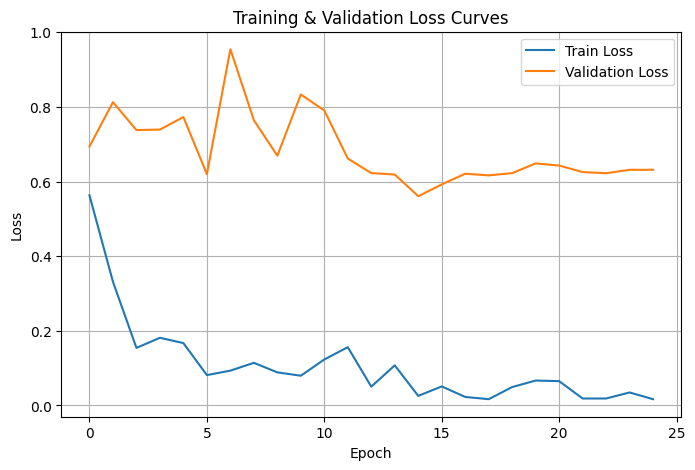

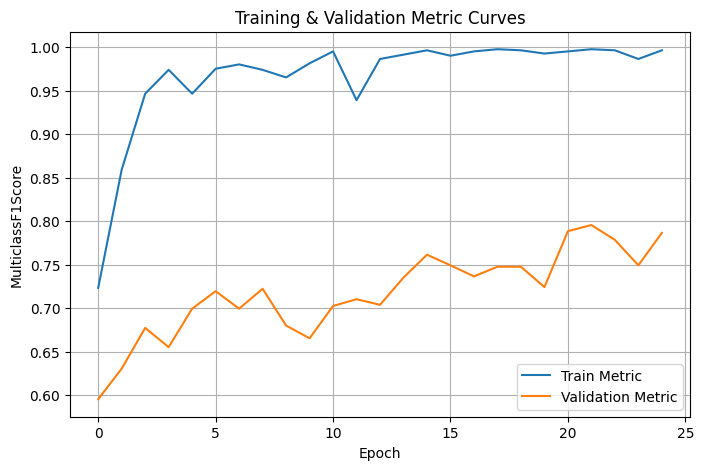

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET18_FT_F1.pt...
Best validation loss: 0.5605
Checkpoint from epoch: 15

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.48s/it]


TEST RESULTS
Test Loss:   0.5695
Test Metric: 0.8053 (80.53%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8615    0.8000    0.8296        70
     Class 1     0.7455    0.8200    0.7810        50

    accuracy                         0.8083       120
   macro avg     0.8035    0.8100    0.8053       120
weighted avg     0.8132    0.8083    0.8093       120



<Figure size 1000x800 with 0 Axes>

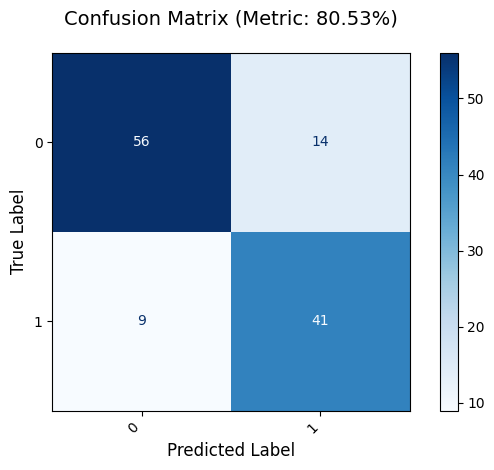


PER-CLASS METRICS
Class 0         | Precision: 0.8615 | Recall: 0.8000 | F1: 0.8296 | Support:   70
Class 1         | Precision: 0.7455 | Recall: 0.8200 | F1: 0.7810 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

#### Transfer learning on ResNet

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Freeze backbone
for p in model.parameters():
  p.requires_grad = False

# Replace classifier with MLP and output NUM_CLASSES
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_TL'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3 # Train MLP
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.6200)
Epoch 1/100 | Train loss: 0.6774, F1: 0.597 | Val loss: 0.6200, F1: 0.624


Epoch 2: Saved new best model (val_loss=0.5501)


Epoch 3: Saved new best model (val_loss=0.5349)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 0.5526, F1: 0.703 | Val loss: 0.6024, F1: 0.632


...

Epoch 25: No improvement (6/10)
Epoch 25/100 | Train loss: 0.4583, F1: 0.777 | Val loss: 0.4985, F1: 0.733


Epoch 26: No improvement (7/10)


Epoch 27: No improvement (8/10)


Epoch 28: No improvement (9/10)


Epoch 29: No improvement (10/10)
Epoch 29: Early stopping triggered.


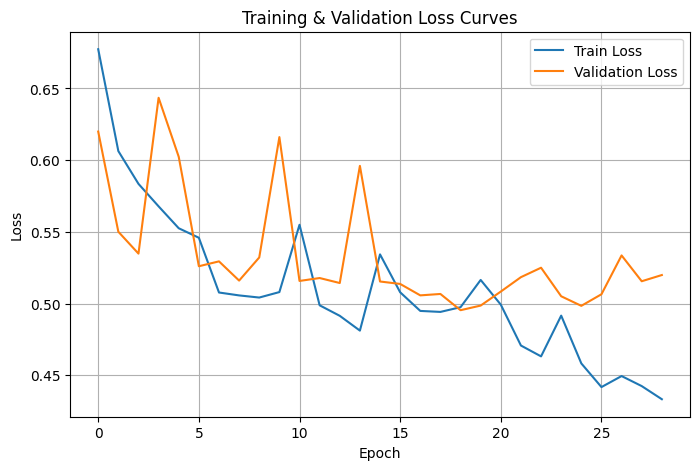

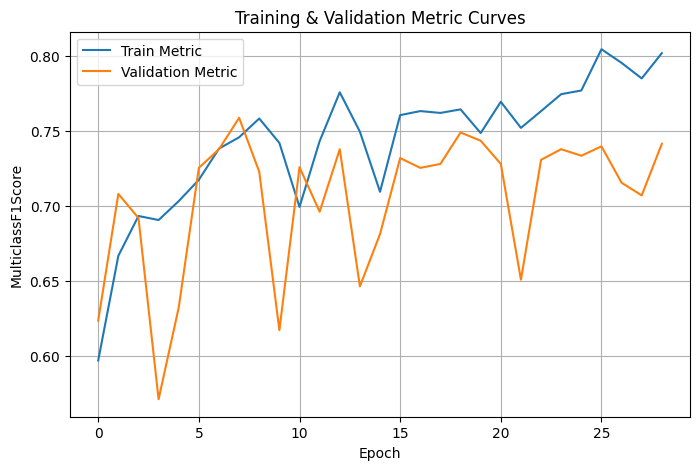

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET18_TL_F1.pt...
Best validation loss: 0.4954
Checkpoint from epoch: 19

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.42s/it]


TEST RESULTS
Test Loss:   0.4990
Test Metric: 0.7068 (70.68%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7500    0.7714    0.7606        70
     Class 1     0.6667    0.6400    0.6531        50

    accuracy                         0.7167       120
   macro avg     0.7083    0.7057    0.7068       120
weighted avg     0.7153    0.7167    0.7158       120



<Figure size 1000x800 with 0 Axes>

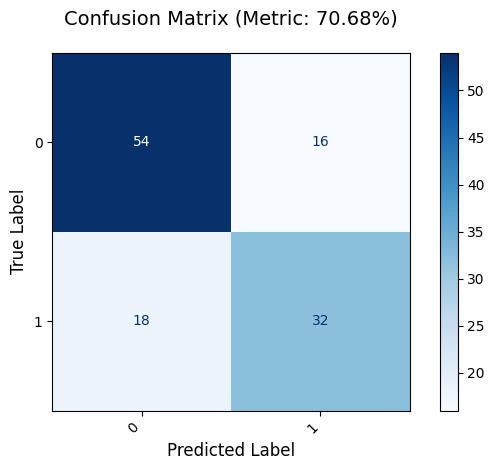


PER-CLASS METRICS
Class 0         | Precision: 0.7500 | Recall: 0.7714 | F1: 0.7606 | Support:   70
Class 1         | Precision: 0.6667 | Recall: 0.6400 | F1: 0.6531 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

## Other architectures

### ResNet50

In [ ]:
# Training ResNet model from scratch
model = models.resnet50(weights=None, num_classes=NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.7030)
Epoch 1/100 | Train loss: 1.0570, F1: 0.527 | Val loss: 0.7030, F1: 0.467


Epoch 2: No improvement (1/10)


Epoch 3: No improvement (2/10)


Epoch 4: No improvement (3/10)


Epoch 5: No improvement (4/10)
Epoch 5/100 | Train loss: 0.7413, F1: 0.616 | Val loss: 0.7703, F1: 0.474


...

Epoch 14: No improvement (6/10)


Epoch 15: No improvement (7/10)
Epoch 15/100 | Train loss: 0.6305, F1: 0.662 | Val loss: 0.6533, F1: 0.579


Epoch 16: No improvement (8/10)


Epoch 17: No improvement (9/10)


Epoch 18: No improvement (10/10)
Epoch 18: Early stopping triggered.


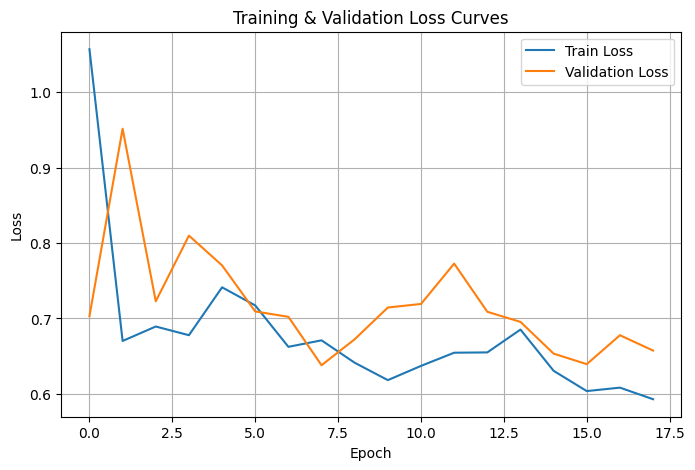

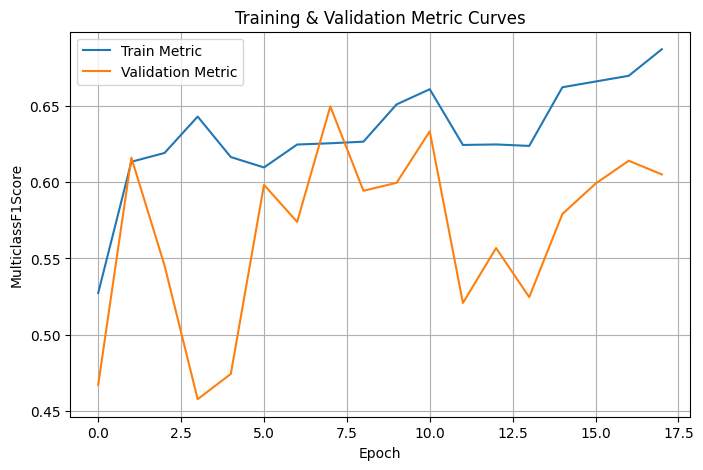

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET50_F1.pt...
Best validation loss: 0.6379
Checkpoint from epoch: 8

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:06<00:00,  1.56s/it]


TEST RESULTS
Test Loss:   0.6304
Test Metric: 0.6683 (66.83%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7313    0.7000    0.7153        70
     Class 1     0.6038    0.6400    0.6214        50

    accuracy                         0.6750       120
   macro avg     0.6676    0.6700    0.6683       120
weighted avg     0.6782    0.6750    0.6762       120



<Figure size 1000x800 with 0 Axes>

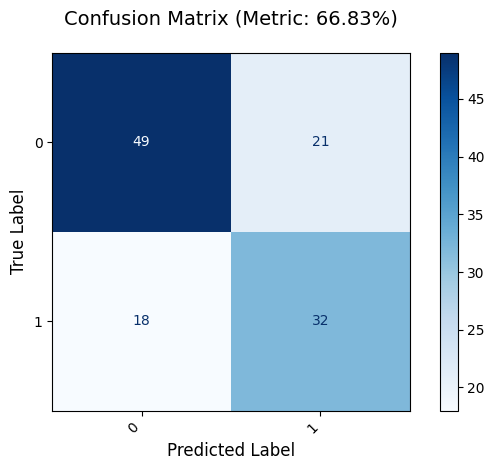


PER-CLASS METRICS
Class 0         | Precision: 0.7313 | Recall: 0.7000 | F1: 0.7153 | Support:   70
Class 1         | Precision: 0.6038 | Recall: 0.6400 | F1: 0.6214 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### ResNet50 Fine-tuning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet50(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50_FT'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Minimize forgetting
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.5074)
Epoch 1/100 | Train loss: 0.6181, F1: 0.684 | Val loss: 0.5074, F1: 0.732


Epoch 2: No improvement (1/10)


Epoch 3: No improvement (2/10)


Epoch 4: No improvement (3/10)


Epoch 5: No improvement (4/10)
Epoch 5/100 | Train loss: 0.1041, F1: 0.975 | Val loss: 0.5415, F1: 0.750


...

Epoch 14: No improvement (6/10)


Epoch 15: No improvement (7/10)
Epoch 15/100 | Train loss: 0.0492, F1: 0.995 | Val loss: 0.5704, F1: 0.798


Epoch 16: No improvement (8/10)


Epoch 17: No improvement (9/10)


Epoch 18: No improvement (10/10)
Epoch 18: Early stopping triggered.


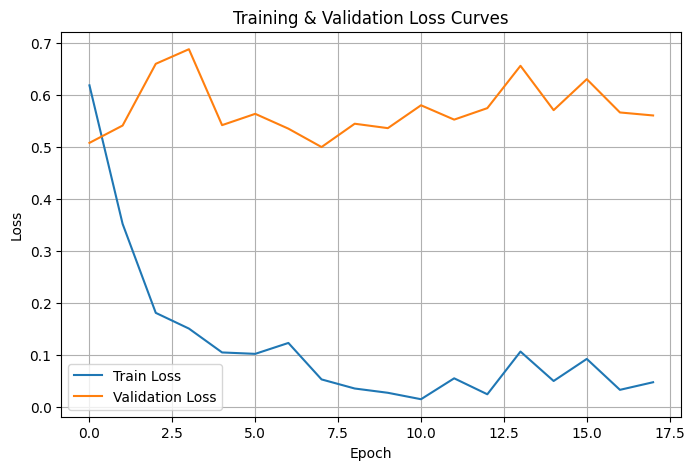

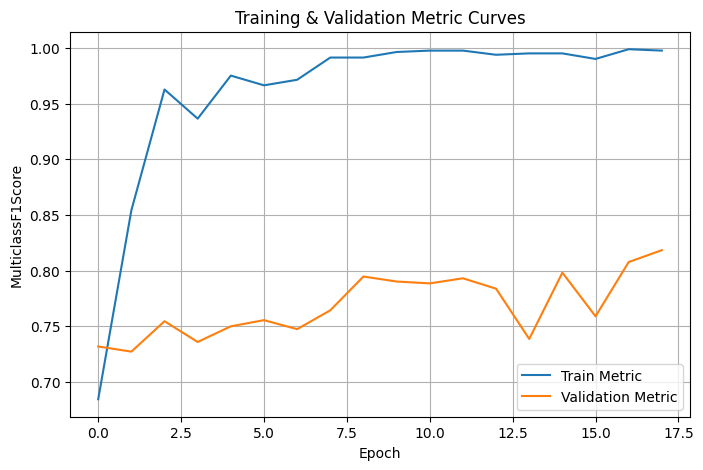

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET50_FT_F1.pt...
Best validation loss: 0.4994
Checkpoint from epoch: 8

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.45s/it]


TEST RESULTS
Test Loss:   0.7160
Test Metric: 0.7412 (74.12%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8545    0.6714    0.7520        70
     Class 1     0.6462    0.8400    0.7304        50

    accuracy                         0.7417       120
   macro avg     0.7503    0.7557    0.7412       120
weighted avg     0.7677    0.7417    0.7430       120



<Figure size 1000x800 with 0 Axes>

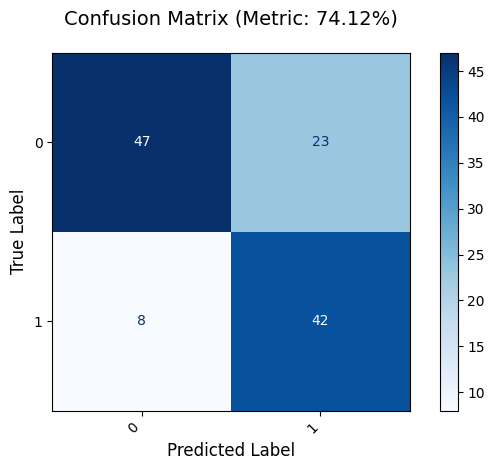


PER-CLASS METRICS
Class 0         | Precision: 0.8545 | Recall: 0.6714 | F1: 0.7520 | Support:   70
Class 1         | Precision: 0.6462 | Recall: 0.8400 | F1: 0.7304 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### ResNet50 Transfer Learning

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet50(weights="DEFAULT")

# Freeze backbone
for p in model.parameters():
  p.requires_grad = False

# Replace classifier with MLP and output NUM_CLASSES
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Paths
MODEL_TYPE = 'RESNET50_TL'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3 # Train MLP
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.6280)
Epoch 1/100 | Train loss: 0.7005, F1: 0.551 | Val loss: 0.6280, F1: 0.589


Epoch 2: Saved new best model (val_loss=0.5941)


Epoch 3: No improvement (1/10)


Epoch 4: Saved new best model (val_loss=0.5677)


Epoch 5: Saved new best model (val_loss=0.5621)
Epoch 5/100 | Train loss: 0.5260, F1: 0.731 | Val loss: 0.5621, F1: 0.693


...

Epoch 16: No improvement (6/10)


Epoch 17: No improvement (7/10)


Epoch 18: No improvement (8/10)


Epoch 19: No improvement (9/10)


Epoch 20: No improvement (10/10)
Epoch 20: Early stopping triggered.


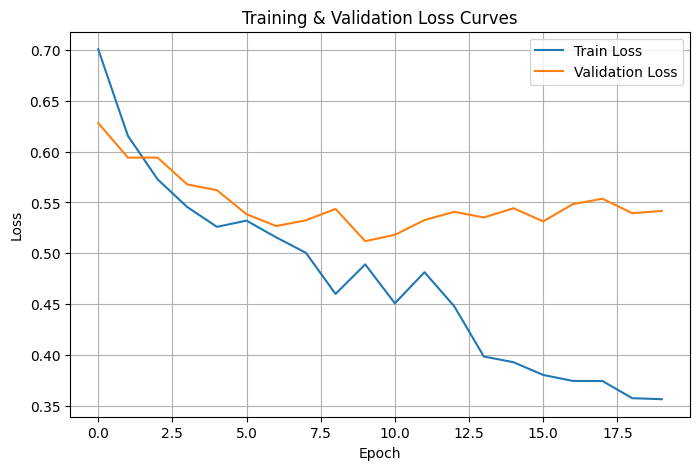

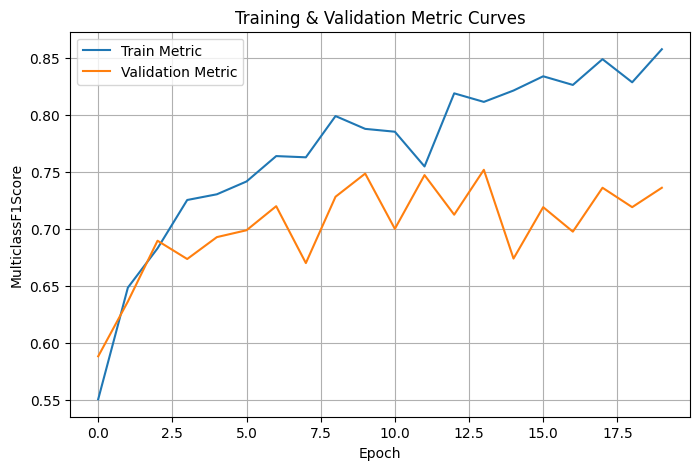

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET50_TL_F1.pt...
Best validation loss: 0.5120
Checkpoint from epoch: 10

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:04<00:00,  1.21s/it]


TEST RESULTS
Test Loss:   0.5029
Test Metric: 0.7488 (74.88%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7561    0.8857    0.8158        70
     Class 1     0.7895    0.6000    0.6818        50

    accuracy                         0.7667       120
   macro avg     0.7728    0.7429    0.7488       120
weighted avg     0.7700    0.7667    0.7600       120



<Figure size 1000x800 with 0 Axes>

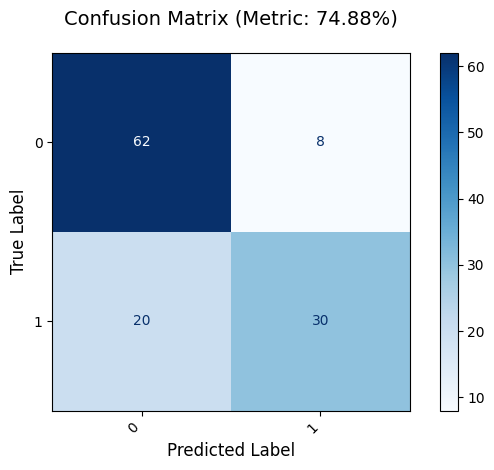


PER-CLASS METRICS
Class 0         | Precision: 0.7561 | Recall: 0.8857 | F1: 0.8158 | Support:   70
Class 1         | Precision: 0.7895 | Recall: 0.6000 | F1: 0.6818 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### EfficientNet

In [ ]:
# Training EfficientNet model from scratch
model = models.efficientnet_b0(weights=None, num_classes=NUM_CLASSES)
print(model)

# Paths
MODEL_TYPE = 'EFFICIENTNET_b0'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.7003)
Epoch 1/100 | Train loss: 3.3329, F1: 0.499 | Val loss: 0.7003, F1: 0.294


Epoch 2: No improvement (1/10)


Epoch 3: Saved new best model (val_loss=0.6821)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 1.1242, F1: 0.543 | Val loss: 1.5021, F1: 0.633


...

Epoch 30: No improvement (6/10)
Epoch 30/100 | Train loss: 0.4664, F1: 0.828 | Val loss: 0.8004, F1: 0.599


Epoch 31: No improvement (7/10)


Epoch 32: No improvement (8/10)


Epoch 33: No improvement (9/10)


Epoch 34: No improvement (10/10)
Epoch 34: Early stopping triggered.


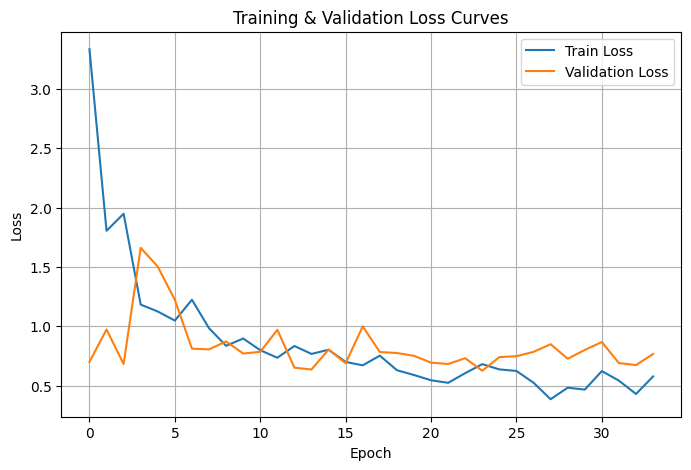

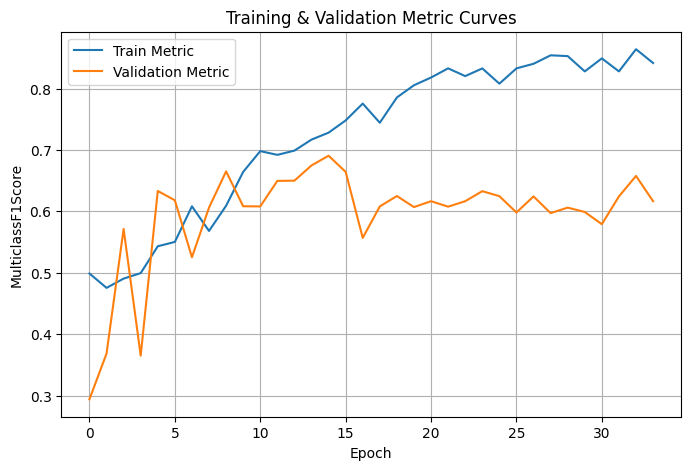

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_EFFICIENTNET_b0_F1.pt...
Best validation loss: 0.6253
Checkpoint from epoch: 24

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:04<00:00,  1.12s/it]


TEST RESULTS
Test Loss:   0.8045
Test Metric: 0.6237 (62.37%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.7193    0.5857    0.6457        70
     Class 1     0.5397    0.6800    0.6018        50

    accuracy                         0.6250       120
   macro avg     0.6295    0.6329    0.6237       120
weighted avg     0.6445    0.6250    0.6274       120



<Figure size 1000x800 with 0 Axes>

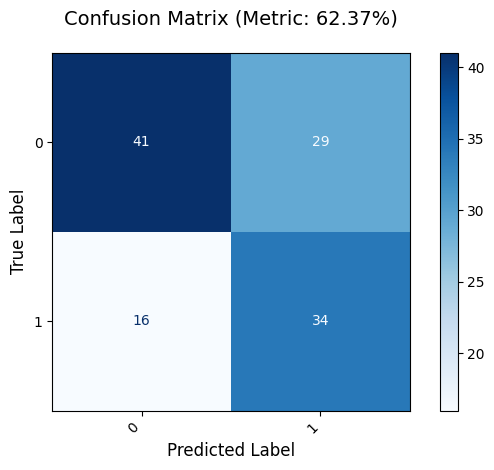


PER-CLASS METRICS
Class 0         | Precision: 0.7193 | Recall: 0.5857 | F1: 0.6457 | Support:   70
Class 1         | Precision: 0.5397 | Recall: 0.6800 | F1: 0.6018 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### DenseNet

In [ ]:
# Training DenseNet model from scratch
model = models.densenet121(weights=None, num_classes=NUM_CLASSES)
print(model)

# Paths
MODEL_TYPE = 'DENSENET121'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.7284)
Epoch 1/100 | Train loss: 0.7123, F1: 0.572 | Val loss: 0.7284, F1: 0.368


Epoch 2: No improvement (1/10)


Epoch 3: Saved new best model (val_loss=0.7202)


Epoch 4: No improvement (1/10)


Epoch 5: Saved new best model (val_loss=0.6174)
Epoch 5/100 | Train loss: 0.6379, F1: 0.623 | Val loss: 0.6174, F1: 0.616


...

Epoch 11: No improvement (6/10)


Epoch 12: No improvement (7/10)


Epoch 13: No improvement (8/10)


Epoch 14: No improvement (9/10)


Epoch 15: No improvement (10/10)
Epoch 15: Early stopping triggered.


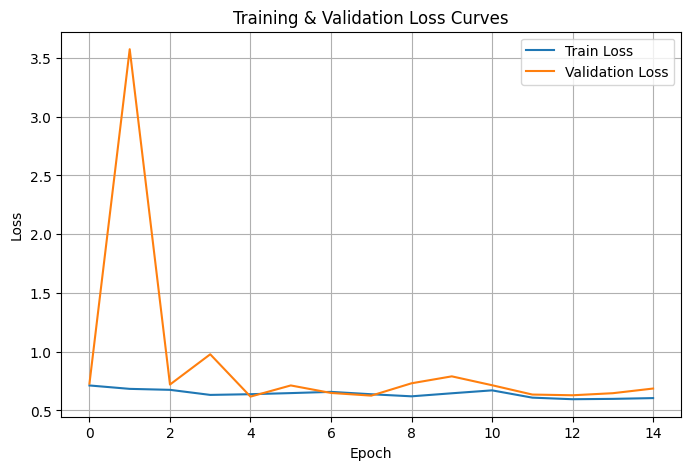

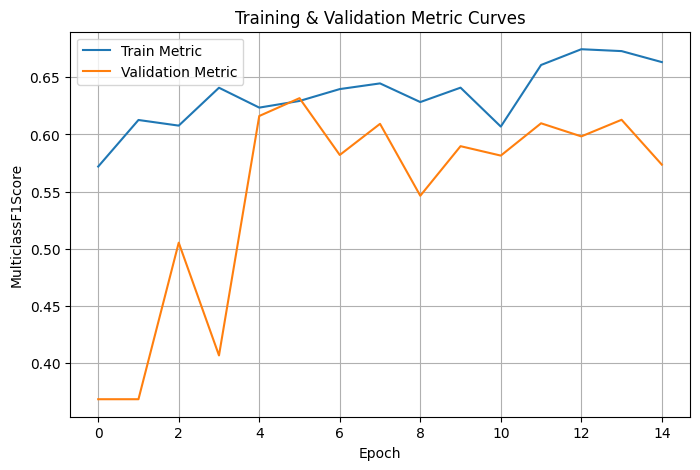

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_DENSENET121_F1.pt...
Best validation loss: 0.6174
Checkpoint from epoch: 5

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.42s/it]


TEST RESULTS
Test Loss:   0.6602
Test Metric: 0.6062 (60.62%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.6556    0.8429    0.7375        70
     Class 1     0.6333    0.3800    0.4750        50

    accuracy                         0.6500       120
   macro avg     0.6444    0.6114    0.6062       120
weighted avg     0.6463    0.6500    0.6281       120



<Figure size 1000x800 with 0 Axes>

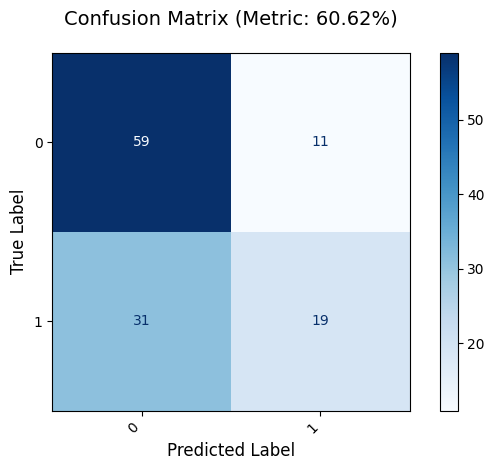


PER-CLASS METRICS
Class 0         | Precision: 0.6556 | Recall: 0.8429 | F1: 0.7375 | Support:   70
Class 1         | Precision: 0.6333 | Recall: 0.3800 | F1: 0.4750 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### ResNet18 using ImageNet normalization (Fine-tuning)
- Use recommended normalization parameters

In [ ]:
# ImageNet normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformations
transform_train = transforms.Compose([
    transforms.Lambda(lambda img: pad_to_square(img, fill=0)), # use function instead
    transforms.RandomHorizontalFlip(), # can consider applying if needed
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_testval = transforms.Compose([
    transforms.Lambda(lambda img: pad_to_square(img, fill=0)), # use function instead
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Load the training, validation, and test sets with defined transformation
train_ds = CustomImageDataset(train_df, transform=transform_train)
val_ds   = CustomImageDataset(val_df,   transform=transform_testval)
test_ds  = CustomImageDataset(test_df,  transform=transform_testval)

In [ ]:
# Setting DataLoader
BATCH_SIZE = 32

# Prepare PyTorch DataLoader objects for batch processing
# Shuffle the training data for better training performance
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_IMAGENET_FT'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Minimize forgetting
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.6020)
Epoch 1/100 | Train loss: 0.6321, F1: 0.657 | Val loss: 0.6020, F1: 0.610


Epoch 2: Saved new best model (val_loss=0.5358)


Epoch 3: Saved new best model (val_loss=0.5040)


Epoch 4: No improvement (1/10)


Epoch 5: No improvement (2/10)
Epoch 5/100 | Train loss: 0.3125, F1: 0.858 | Val loss: 0.5596, F1: 0.729


...

Epoch 9: No improvement (6/10)


Epoch 10: No improvement (7/10)
Epoch 10/100 | Train loss: 0.1162, F1: 0.965 | Val loss: 0.7124, F1: 0.693


Epoch 11: No improvement (8/10)


Epoch 12: No improvement (9/10)


Epoch 13: No improvement (10/10)
Epoch 13: Early stopping triggered.


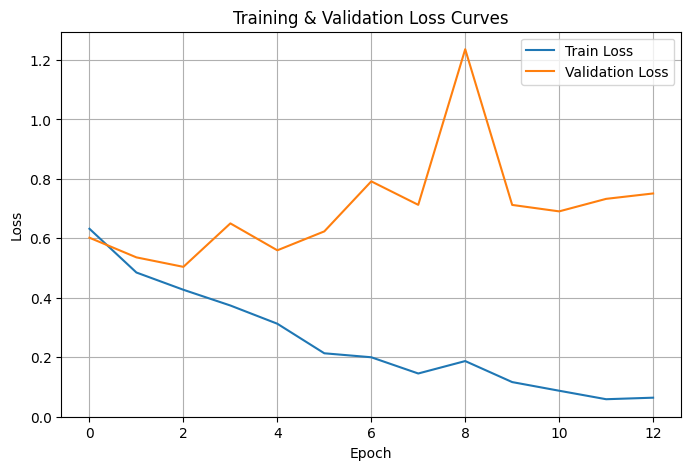

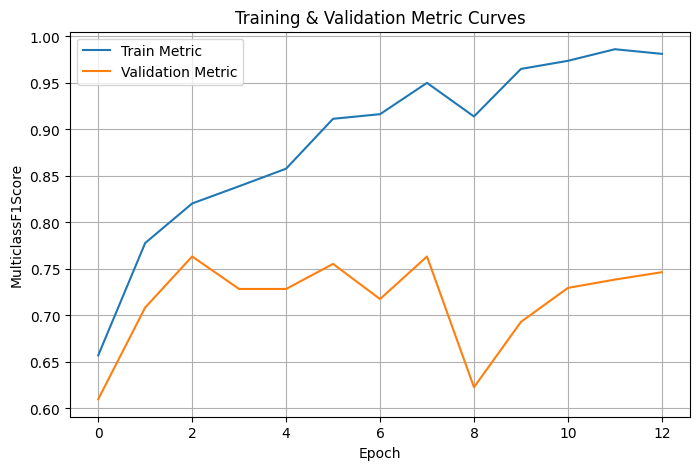

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET18_IMAGENET_FT_F1.pt...
Best validation loss: 0.5040
Checkpoint from epoch: 3

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.31s/it]


TEST RESULTS
Test Loss:   0.5332
Test Metric: 0.7643 (76.43%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8387    0.7429    0.7879        70
     Class 1     0.6897    0.8000    0.7407        50

    accuracy                         0.7667       120
   macro avg     0.7642    0.7714    0.7643       120
weighted avg     0.7766    0.7667    0.7682       120



<Figure size 1000x800 with 0 Axes>

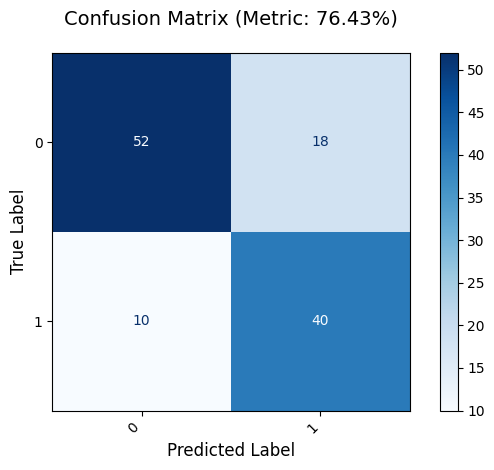


PER-CLASS METRICS
Class 0         | Precision: 0.8387 | Recall: 0.7429 | F1: 0.7879 | Support:   70
Class 1         | Precision: 0.6897 | Recall: 0.8000 | F1: 0.7407 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)

### ResNet18 (Fine-tuning) with augmentation

In [ ]:
# Transformations
transform_train = transforms.Compose([
    transforms.Lambda(lambda img: pad_to_square(img, fill=0)), # use function instead
    transforms.RandomHorizontalFlip(), # can consider applying if needed
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

transform_testval = transforms.Compose([
    transforms.Lambda(lambda img: pad_to_square(img, fill=0)), # use function instead
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD)
])

# Load the training, validation, and test sets with defined transformation
train_ds = CustomImageDataset(train_df, transform=transform_train)
val_ds   = CustomImageDataset(val_df,   transform=transform_testval)
test_ds  = CustomImageDataset(test_df,  transform=transform_testval)

In [ ]:
# Setting DataLoader
BATCH_SIZE = 32

# Prepare PyTorch DataLoader objects for batch processing
# Shuffle the training data for better training performance
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Using pretrained ResNet with ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Replace the final fully-connected layer to match the number of output classes for out dataset
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Paths
MODEL_TYPE = 'RESNET18_AUGMENTATION_FT'
CHECKPOINT_FILE = f"/content/checkpoint_{MODEL_TYPE}_F1.pt"

# Set up alternative metrics
train_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
val_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)

# Set up optimizer and scheduler
LEARNING_RATE = 1e-4 # Minimize forgetting
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, factor=0.1, patience=5)

# Move model to GPU
model = model.to(DEVICE)

In [ ]:
# ---- Tracking ----
best_val_loss = float("inf")
no_improve_count = 0

running_train_loss, running_train_metric = [], []
running_val_loss, running_val_metric = [], []

# ---- Epoch loop ----
for epoch in range(NUM_EPOCHS):
  avg_train_loss, avg_train_metric = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, DEVICE)
  avg_val_loss, avg_val_metric = validate_one_epoch(model, val_loader, criterion, val_metric, DEVICE)

  # Track metrics
  running_train_loss.append(avg_train_loss)
  running_train_metric.append(avg_train_metric)
  running_val_loss.append(avg_val_loss)
  running_val_metric.append(avg_val_metric)

  # Scheduler step
  scheduler.step(avg_val_loss)

  # ---- Checkpointing + Early Stopping ----
  if avg_val_loss < best_val_loss - MIN_DELTA:
    best_val_loss = avg_val_loss
    no_improve_count = 0
    torch.save({
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }, CHECKPOINT_FILE)
    print(f"Epoch {epoch+1}: Saved new best model (val_loss={best_val_loss:.4f})")
  else:
    no_improve_count += 1
    print(f"Epoch {epoch+1}: No improvement ({no_improve_count}/{PATIENCE})")
    if no_improve_count >= PATIENCE:
      print(f"Epoch {epoch+1}: Early stopping triggered.")
      break

  # ---- Reporting ----
  if (epoch + 1) % REPORT_INTERVAL == 0 or (epoch + 1) == 1 or (epoch + 1) == NUM_EPOCHS:
      print(
          f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f}, F1: {avg_train_metric:.3f} | "
          f"Val loss: {avg_val_loss:.4f}, F1: {avg_val_metric:.3f}"
      )

Epoch 1: Saved new best model (val_loss=0.5923)
Epoch 1/100 | Train loss: 0.6563, F1: 0.659 | Val loss: 0.5923, F1: 0.637


Epoch 2: Saved new best model (val_loss=0.4750)


Epoch 3: No improvement (1/10)


Epoch 4: No improvement (2/10)


Epoch 5: No improvement (3/10)
Epoch 5/100 | Train loss: 0.3001, F1: 0.892 | Val loss: 0.5560, F1: 0.693


...

Epoch 16: No improvement (6/10)


Epoch 17: No improvement (7/10)


Epoch 18: No improvement (8/10)


Epoch 19: No improvement (9/10)


Epoch 20: No improvement (10/10)
Epoch 20: Early stopping triggered.


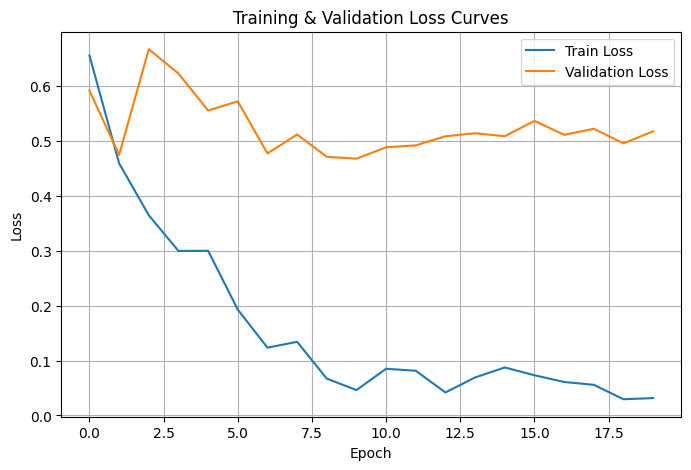

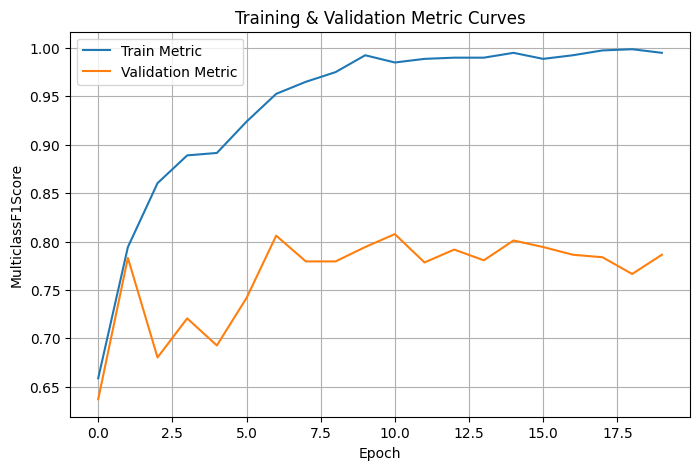

In [ ]:
# Loss and metric curves
loss_curves(running_train_loss, running_val_loss, running_train_metric, running_val_metric, metric = metric_name)

Loading model from /content/checkpoint_RESNET18_AUGMENTATION_FT_F1.pt...
Best validation loss: 0.4681
Checkpoint from epoch: 10

Evaluating on test set...


Testing: 100%|██████████| 4/4 [00:05<00:00,  1.42s/it]


TEST RESULTS
Test Loss:   0.5209
Test Metric: 0.7863 (78.63%)
Total Samples: 120

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.8261    0.8143    0.8201        70
     Class 1     0.7451    0.7600    0.7525        50

    accuracy                         0.7917       120
   macro avg     0.7856    0.7871    0.7863       120
weighted avg     0.7923    0.7917    0.7919       120



<Figure size 1000x800 with 0 Axes>

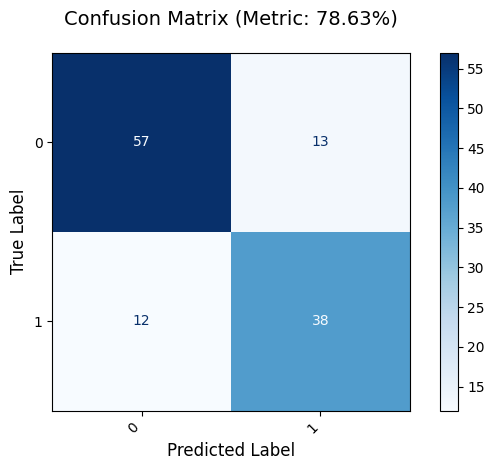


PER-CLASS METRICS
Class 0         | Precision: 0.8261 | Recall: 0.8143 | F1: 0.8201 | Support:   70
Class 1         | Precision: 0.7451 | Recall: 0.7600 | F1: 0.7525 | Support:   50


In [ ]:
# Evaluate on test set
test_metric = MulticlassF1Score(num_classes=NUM_CLASSES, average="macro").to(DEVICE)
results = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    test_metric=test_metric,
    checkpoint_file=CHECKPOINT_FILE,
    device=DEVICE
)